In [17]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='ticks')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42


In [2]:
exp_df_ = pd.read_excel("../datasets/yang/GSE228251_expression.xlsx", header=1)
exp_df = exp_df_.drop_duplicates(subset=['gene_name'])
exp_df.index = exp_df['gene_name'].values

In [3]:
gene_info_cols = ['gene_name', 'gene_id', 'gene_type', 'Chr', 'Start', 'End', 'Strand', 'Length']


In [4]:
group_dict = {
    "WT_no_stimulation": ["XRN1014", "XRN1015", "XRN1016"],
    "KO_no_stimulation": ["XRN1017", "XRN1018", "XRN1019"],
    "WT_IL4_stimulation": ["XRN1026", "XRN1027", "XRN1028"],
    "KO_IL4_stimulation": ["XRN1029", "XRN1030", "XRN1031"]
}
sample_list = np.array(sum(list(group_dict.values()), []))
smp2cond = {ii: j for j, i in group_dict.items() for ii in i}

In [5]:
exp_ad = sc.AnnData(
    # X=exp_df[sample_list + ['.logCPM']].values.T,
    X=exp_df[sample_list].values.T,
    layers={
        'raw': exp_df[sample_list].values.T,
        'logCPM': exp_df[sample_list + ['.logCPM']].values.T,
        'logRPKM': exp_df[sample_list + ['.logRPKM']].values.T
    },
    obs=pd.DataFrame(index=sample_list).assign(group=lambda x: x.index.map(smp2cond)),
    var=exp_df[gene_info_cols]
)
sc.pp.normalize_total(exp_ad, target_sum=1e6)
sc.pp.log1p(exp_ad)
exp_ad.layers['log1p'] = exp_ad.X.copy()
sc.pp.scale(exp_ad)
exp_ad.layers['scaled'] = exp_ad.X.copy()
sample_mean = exp_ad.layers['logCPM'].mean(axis=0, keepdims=True)
sample_std = exp_ad.layers['logCPM'].std(axis=0, keepdims=True)
exp_ad.layers['logCPM.scaled'] = (exp_ad.layers['logCPM'] - sample_mean) / sample_std

In [6]:
gene_dict = yaml.safe_load(open("../datasets/yang/macrophage_gene_list.yaml"))
g2m_dict = {g:m for m,gs in gene_dict.items() for g in gs}
exp_ad.var['M1/M2'] = exp_ad.var['gene_name'].map(lambda x: g2m_dict.get(x, 'other'))

In [7]:
edger_df = exp_df[[c for c in exp_df.columns if '_vs_' in c]]
edger_df

,logFC.KO_no_stimulation_vs_WT_no_stimulation,logCPM.KO_no_stimulation_vs_WT_no_stimulation,PValue.KO_no_stimulation_vs_WT_no_stimulation,FDR.KO_no_stimulation_vs_WT_no_stimulation,logFC.KO_IL4_stimulation_vs_WT_IL4_stimulation,logCPM.KO_IL4_stimulation_vs_WT_IL4_stimulation,PValue.KO_IL4_stimulation_vs_WT_IL4_stimulation,FDR.KO_IL4_stimulation_vs_WT_IL4_stimulation,logFC.WT_IL4_stimulation_vs_WT_no_stimulation,logCPM.WT_IL4_stimulation_vs_WT_no_stimulation,PValue.WT_IL4_stimulation_vs_WT_no_stimulation,FDR.WT_IL4_stimulation_vs_WT_no_stimulation,logFC.KO_IL4_stimulation_vs_KO_no_stimulation,logCPM.KO_IL4_stimulation_vs_KO_no_stimulation,PValue.KO_IL4_stimulation_vs_KO_no_stimulation,FDR.KO_IL4_stimulation_vs_KO_no_stimulation
Hilpda,2.699162,6.147609,8.195945e-112,1.124074e-107,2.901591,6.147609,2.431979e-124,3.335459e-120,-0.634631,6.147609,1.136998e-07,1.365493e-06,-0.432202,6.147609,9.950115e-05,6.775860e-04
Pf4,3.673627,8.296772,6.846900e-96,4.695262e-92,3.472129,8.296772,1.600725e-87,1.097697e-83,0.103583,8.296772,5.193344e-01,6.979590e-01,-0.097915,8.296772,5.364678e-01,6.818936e-01
Il1rn,1.841268,4.454148,3.839390e-47,1.755241e-43,1.844867,4.454148,1.308793e-44,1.994456e-41,-0.736206,4.454148,3.774892e-08,4.935428e-07,-0.732608,4.454148,1.791602e-09,2.989272e-08
Nr4a1,1.951329,4.214787,4.097142e-46,1.404807e-42,2.907766,4.214787,4.008190e-79,1.832411e-75,-2.005562,4.214787,1.001266e-37,1.017212e-35,-1.049125,4.214787,1.343754e-15,4.059381e-14
Acp5,1.193363,7.318915,2.233289e-44,6.125911e-41,1.011473,7.318915,9.895878e-34,9.694426e-31,1.194957,7.318915,1.463328e-44,1.987084e-42,1.013066,7.318915,8.956451e-34,8.774124e-32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pla2g4d,0.000000,-2.160917,1.000000e+00,1.000000e+00,0.693914,-2.160917,2.035358e-01,4.207987e-01,6.127309,-2.160917,3.600303e-07,4.037462e-06,6.821223,-2.160917,1.452373e-09,2.456140e-08
Mir9-3hg,0.000000,-2.019614,1.000000e+00,1.000000e+00,-0.487484,-2.019614,3.265391e-01,5.610968e-01,6.877185,-2.019614,1.906853e-10,3.387629e-09,6.389701,-2.019614,2.183155e-08,3.128732e-07
Gm6522,0.000000,-1.401568,1.000000e+00,1.000000e+00,0.329172,-1.401568,4.210477e-01,6.500810e-01,7.262670,-1.401568,2.792719e-13,6.684493e-12,7.591842,-1.401568,2.746486e-15,8.118115e-14
Gm19951,0.000000,-1.668274,1.000000e+00,1.000000e+00,1.297482,-1.668274,7.140422e-03,3.749268e-02,6.347994,-1.668274,3.041133e-08,4.029869e-07,7.645477,-1.668274,3.604043e-14,9.768666e-13


In [8]:
from edger_to_rank_genes_groups import add_multiple_rank_genes_groups_to_anndata

add_multiple_rank_genes_groups_to_anndata(
    exp_ad, 
    edger_df,
    key_prefix='rank_genes_groups',
    group_by_reference=True,
    groupby='group'
)


Processing reference group 'KO_no_stimulation': 1 comparisons
Processing reference group 'WT_IL4_stimulation': 1 comparisons
Processing reference group 'WT_no_stimulation': 2 comparisons
Added results to adata.uns['rank_genes_groups_KO_no_stimulation']
Added results to adata.uns['rank_genes_groups_WT_IL4_stimulation']
Added results to adata.uns['rank_genes_groups_WT_no_stimulation']


AnnData object with n_obs × n_vars = 12 × 13707
    obs: 'group'
    var: 'gene_name', 'gene_id', 'gene_type', 'Chr', 'Start', 'End', 'Strand', 'Length', 'mean', 'std', 'M1/M2'
    uns: 'log1p', 'rank_genes_groups_KO_no_stimulation', 'rank_genes_groups_WT_IL4_stimulation', 'rank_genes_groups_WT_no_stimulation'
    layers: 'raw', 'logCPM', 'logRPKM', 'log1p', 'scaled', 'logCPM.scaled'

In [9]:
q_threshold = 0.05
logfc_threshold = 1
selected_groups = ['WT_IL4_stimulation_vs_WT_no_stimulation', 'KO_IL4_stimulation_vs_KO_no_stimulation']
    
degs_dict = {
    col: np.intersect1d(
        edger_df['PValue.'+col][lambda x: x < q_threshold].index.values,
        edger_df['logFC.'+col][lambda x: abs(x) > logfc_threshold].index.values
    )
    for col in selected_groups
}
degs = np.unique(np.concatenate(list(degs_dict.values())))
exp_ad.var['degs'] = exp_ad.var_names.isin(degs)
# exp_ad.var['degs'] = True
print({k:len(v) for k,v in degs_dict.items()})
print('total', len(degs))

{'WT_IL4_stimulation_vs_WT_no_stimulation': 1076, 'KO_IL4_stimulation_vs_KO_no_stimulation': 1154}
total 1534


In [10]:
group_colors = {
    'WT_no_stimulation': '#999999',
    'KO_no_stimulation': '#B87AD5FF',
    'WT_IL4_stimulation': '#4B4B4BFF',
    'KO_IL4_stimulation': '#A12FD6FF'
}
annot_colors = pd.Series({
    s:group_colors[g] for s,g in smp2cond.items()
})

In [11]:
plot_ad = exp_ad[:,exp_ad.var['degs']].copy()
plot_ad.X = plot_ad.layers['logCPM.scaled']

In [12]:
plot_ad

AnnData object with n_obs × n_vars = 12 × 1534
    obs: 'group'
    var: 'gene_name', 'gene_id', 'gene_type', 'Chr', 'Start', 'End', 'Strand', 'Length', 'mean', 'std', 'M1/M2', 'degs'
    uns: 'log1p', 'rank_genes_groups_KO_no_stimulation', 'rank_genes_groups_WT_IL4_stimulation', 'rank_genes_groups_WT_no_stimulation'
    layers: 'raw', 'logCPM', 'logRPKM', 'log1p', 'scaled', 'logCPM.scaled'

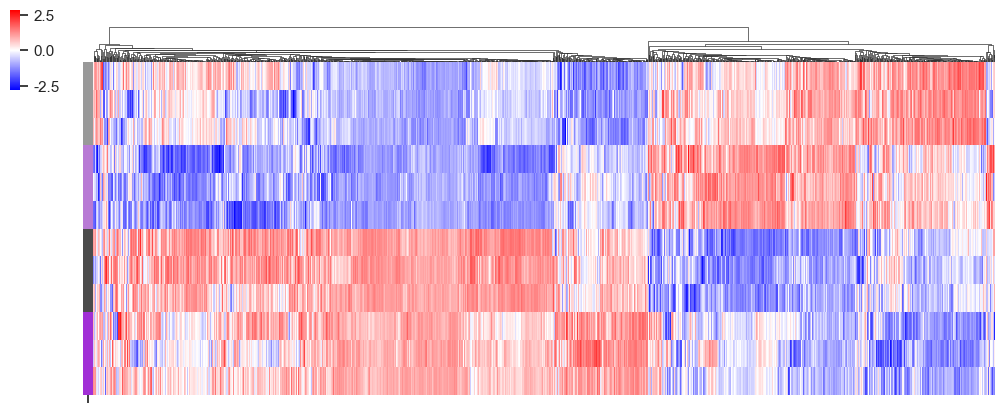

In [ ]:
sc.pl.clustermap(
    plot_ad, 
    # obs_keys='group', 
    dendrogram_ratio=(0.06, 0.1), 
    figsize=(10, 4), 
    cmap='bwr', 
    center=0,
    xticklabels=False,
    yticklabels=False,
    row_colors=annot_colors,
    row_cluster=False,
    colors_ratio=0.01,
    cbar_pos=(0.00, 0.8, 0.01, 0.2),
    metric='correlation',
    show=False
)
plt.savefig('../figures/4_macrophages_bulk_degs_clustermap.pdf', bbox_inches='tight')
plt.show()

In [14]:
from scipy.stats import ttest_ind

In [15]:
extracted_ad = exp_ad.copy()
extracted_df = extracted_ad.to_df(layer='logCPM')
extracted_df['WT'] = extracted_ad.obs['group'].str.contains('WT')
extracted_df['group'] = extracted_ad.obs['group'].apply(lambda x: 'No stimulation' if x.split('_')[1] == 'no' else 'IL-4 stimulation')
extracted_df = extracted_df.melt(
    id_vars=['group', 'WT'],
    var_name='gene_name',
    value_name='expression'
)
extracted_df['M1/M2'] = extracted_df['gene_name'].map(lambda x: g2m_dict.get(x, 'other'))
extracted_df_trans = pd.merge(
    extracted_df,
    (
        extracted_df
        .groupby(['group', 'gene_name', 'M1/M2', 'WT'])
        .agg('mean')
        .reset_index()
        .rename(columns={'expression': 'WT_mean'})
        .query('WT')
        .drop(columns=['WT'])
    ),
    on=['group', 'gene_name', 'M1/M2'],
)
extracted_df_trans[r"$\Delta\log$CPM"] = extracted_df_trans['expression'] - extracted_df_trans['WT_mean']
extracted_df_trans['label'] = extracted_df_trans['WT'].map(lambda x: 'WT cell' if x else 'KO cell') + ' (' + extracted_df_trans['group'] + ')'
extracted_df_trans['KO'] = ~extracted_df_trans['WT']
extracted_df_trans['Sample'] = extracted_df_trans['KO'].apply(lambda x: 'Stk11 KO' if x else 'WT')

extracted_df_trans

,group,WT,gene_name,expression,M1/M2,WT_mean,$\Delta\log$CPM,label,KO,Sample
0,No stimulation,True,Hilpda,4.281593,other,4.450057,-0.168464,WT cell (No stimulation),False,WT
1,No stimulation,True,Hilpda,4.536486,other,4.450057,0.086429,WT cell (No stimulation),False,WT
2,No stimulation,True,Hilpda,4.532092,other,4.450057,0.082035,WT cell (No stimulation),False,WT
3,No stimulation,False,Hilpda,7.095845,other,4.450057,2.645788,KO cell (No stimulation),True,Stk11 KO
4,No stimulation,False,Hilpda,7.235223,other,4.450057,2.785165,KO cell (No stimulation),True,Stk11 KO
...,...,...,...,...,...,...,...,...,...,...
164479,IL-4 stimulation,True,Gm49087,-0.888633,other,-0.493014,-0.395619,WT cell (IL-4 stimulation),False,WT
164480,IL-4 stimulation,True,Gm49087,-0.447418,other,-0.493014,0.045596,WT cell (IL-4 stimulation),False,WT
164481,IL-4 stimulation,False,Gm49087,-1.863194,other,-0.493014,-1.370180,KO cell (IL-4 stimulation),True,Stk11 KO
164482,IL-4 stimulation,False,Gm49087,-0.790795,other,-0.493014,-0.297781,KO cell (IL-4 stimulation),True,Stk11 KO


In [16]:
extracted_df_trans['M1/M2'] = extracted_df_trans['gene_name'].map(lambda x: g2m_dict.get(x, 'other'))

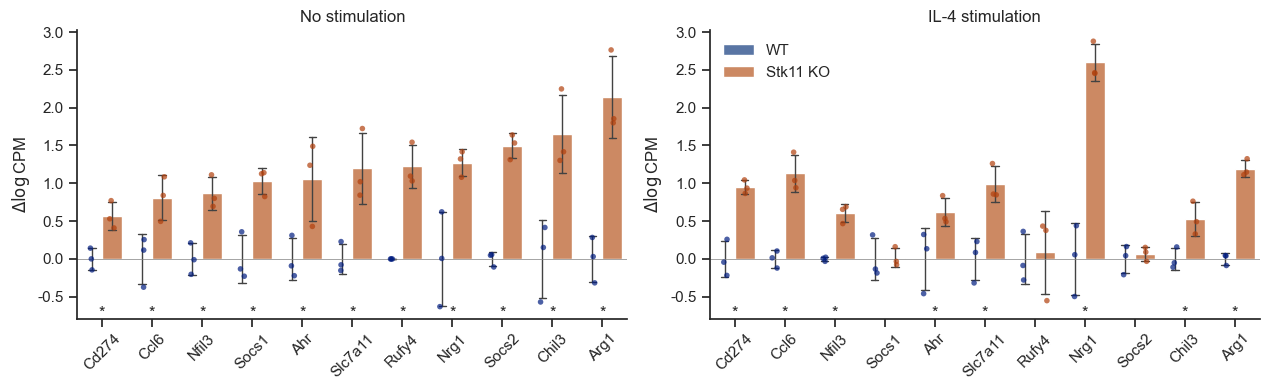

In [ ]:
# Bar plot with points, remove ylabel
data_subset = extracted_df_trans.loc[extracted_df_trans['M1/M2'] == 'm2'].copy()
sig_df = (
    data_subset
    .groupby(['group', 'gene_name', 'M1/M2'])
    .apply(
        lambda x: pd.Series({'pvalue': ttest_ind(
            x.query('not WT')['expression'], 
            x.query('WT')['expression'], 
            alternative='greater'
        ).pvalue}),
        include_groups=False
    )
    .reset_index()
)

order = data_subset.query('KO and group == "No stimulation"').groupby(['gene_name'])[r"$\Delta\log$CPM"].mean().sort_values().index
yaxis_min = data_subset[r"$\Delta\log$CPM"].min()
yaxis_max = data_subset[r"$\Delta\log$CPM"].max()
# Create bar plot
g = sns.catplot(
    data=data_subset,
    x='gene_name',
    order=order,
    y=r"$\Delta\log$CPM",
    hue='Sample',
    kind='bar',
    col='group',
    sharex=False,
    sharey=False,
    estimator='mean',
    errorbar='sd',
    capsize=0.3,
    err_kws={'linewidth': 1},
    dodge=True,
    aspect=1.6,
    height=4,
    facet_kws={'ylim': (yaxis_min * 1.25, yaxis_max * 1.05)},
    legend_out=False,
)


g.set_titles('{col_name}')
g.set_xticklabels(rotation=45)

# Overlay points on the bar plot
for ax in g.axes.flat:
    group = ax.get_title()
    ax.axhline(0, color='gray', linewidth=0.5)
    sns.stripplot(
        data=data_subset.loc[data_subset['group'] == group],
        x='gene_name',
        order=order,
        y=r"$\Delta\log$CPM",
        hue='Sample',
        dodge=True,
        ax=ax,
        size=4,
        alpha=0.7,
        palette='dark',
        legend=False
    )
    # _ = plt.setp(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')  # Remove xlabel
    for gene in order:
        p = sig_df.query('gene_name == @gene and group == @group')['pvalue'].values[0]
        ax.text(
            gene,
            yaxis_min * 1.15,
            "*" if p < 0.05 else "",
            ha='center',
            va='center',
            fontsize=12
        )
    ax.legend(frameon=False, title='', loc='upper left')
plt.tight_layout()
plt.savefig('../figures/4_macrophage_bulk_ko_SKT11_m2_barplot.pdf', bbox_inches='tight')
plt.show()

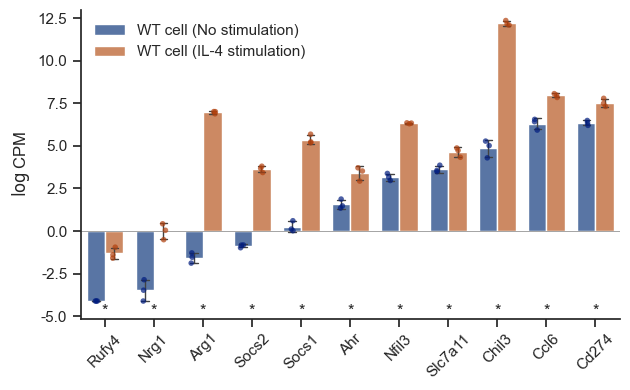

In [ ]:
data_subset = extracted_df_trans.loc[(extracted_df_trans['M1/M2'] == 'm2') & (extracted_df_trans['WT'])].copy()
sig_df = (
    data_subset
    .groupby(['gene_name', 'M1/M2'])
    .apply(
        lambda x: pd.Series({'pvalue': ttest_ind(
            x.query('group == "IL-4 stimulation"')['expression'], 
            x.query('group == "No stimulation"')['expression'], 
            alternative='greater'
        ).pvalue}),
        include_groups=False
    )
    .reset_index()
)

order = data_subset.query('group == "No stimulation"').groupby(['gene_name'])["expression"].mean().sort_values().index
yaxis_min = data_subset["expression"].min()
yaxis_max = data_subset["expression"].max()
# Create bar plot
g = sns.catplot(
    data=data_subset,
    x='gene_name',
    order=order,
    y="expression",
    hue='label',
    kind='bar',
    sharex=False,
    estimator='mean',
    width=0.75,
    errorbar='sd',
    capsize=0.3,
    err_kws={'linewidth': 1},
    dodge=True,
    aspect=1.6,
    height=4,
    facet_kws={'ylim': (yaxis_min * 1.25, yaxis_max * 1.05)},
    legend_out=False,
)


g.set_titles('{col_name}')
g.set_xticklabels(rotation=45)

# Overlay points on the bar plot
ax = g.axes.flat[0]
ax.axhline(0, color='gray', linewidth=0.5)
sns.stripplot(
    data=data_subset,
    x='gene_name',
    order=order,
    y="expression",
    hue='label',
    dodge=True,
    ax=ax,
    size=4,
    alpha=0.7,
    palette='dark',
    legend=False
)
# _ = plt.setp(ax.get_xticklabels(), rotation=45)
ax.set_xlabel('')  # Remove xlabel
ax.set_ylabel(r'$\log$CPM')
for gene in order:
    p = sig_df.query('gene_name == @gene')['pvalue'].values[0]
    ax.text(
        gene,
        yaxis_min * 1.15,
        "*" if p < 0.05 else "",
        ha='center',
        va='center',
        fontsize=12
    )
ax.legend(frameon=False, title='')
plt.tight_layout()
plt.savefig('../figures/4_macrophages_bulk_wt_il4_m2_barplot.pdf', bbox_inches='tight')
plt.show()